In [1]:
import torch
from torch import nn
import sys
sys.path.append("..")
from tools.PLOT import plot 

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
num_inputs,num_outputs,num_hiddens=784,10,256
W1=nn.Parameter(torch.randn(num_inputs,num_hiddens,requires_grad=True,device=device)*0.1)
b1=nn.Parameter(torch.zeros(num_hiddens,requires_grad=True,device=device))
W2=nn.Parameter(torch.randn(num_hiddens,num_outputs,requires_grad=True,device=device)*0.1)
b2=nn.Parameter(torch.zeros(num_outputs,requires_grad=True,device=device))
params=[W1,b1,W2,b2]

In [4]:
def relu(X):
  a=torch.zeros_like(X)
  return torch.max(X,a)

In [5]:
def net(X):
  X=X.reshape((-1,num_inputs))
  H=relu(X@W1+b1)
  return (H@W2+b2)

In [6]:
loss=nn.CrossEntropyLoss(reduction='none')

In [7]:
num_epochs,lr=10,0.1
update=torch.optim.SGD(params,lr=lr)

In [8]:
from torchvision import transforms
import torchvision
from torch.utils import data

trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=False)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=False)
batch_size = 256
train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True)
test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False)

In [9]:
from tools.ACCURACY import evalute_acc


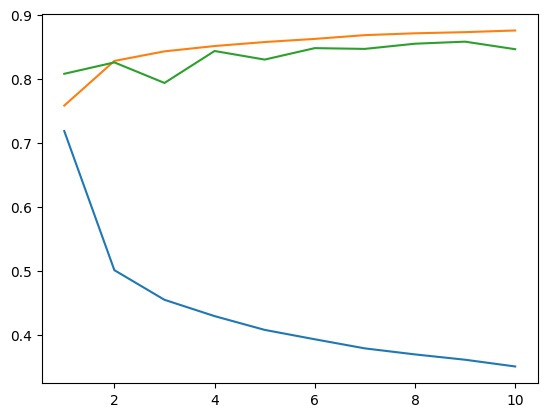

In [10]:
train_loss,train_acc,test_acc=[],[],[]
%matplotlib inline
import matplotlib.pyplot as plt
from IPython import display
plt.ion()
for epoch in range(num_epochs):
  # net.train()
  total_loss,correct,total=0.0,0,0
  for X,y in train_iter:
    X,y=X.to(device),y.to(device)
    X=X.reshape(X.shape[0],-1)
    y_hat=net(X)
    l=loss(y_hat,y).mean()
    update.zero_grad()
    l.backward()
    update.step()
    total_loss+=l.item()*X.shape[0]
    correct+=(y_hat.argmax(dim=1)==y).sum().item()
    total+=y.shape[0]
  train_loss.append(total_loss/total)
  train_acc.append(correct/total)
  test_acc.append(evalute_acc(net,test_iter,device))
  print(f"epoch {epoch+1}, loss {total_loss/total:.6f}, train acc {correct/total:.6f}, test acc {test_acc[-1]:.6f}")
  
  display.clear_output(wait=True)
  plt.cla()
  epoch_range=range(1,len(train_loss)+1)
  plt.plot(epoch_range,train_loss,label='train loss')
  plt.plot(epoch_range,train_acc,label='train acc')
  plt.plot(epoch_range,test_acc,label='test acc')
  # plt.grad(True)
  plt.show()
  plt.pause(0.01)

plt.ioff()          
plt.show()  